BASELINE 1 — MAJORITY CLASSIFIER
Golden examples       : 200
Majority intent       : Delivery Issue
Correct predictions   : 68
Incorrect predictions : 132

OVERALL METRICS
---------------------------------------------------------------------------
Accuracy              : 0.340 (34.00%)
Macro Precision       : 0.031
Macro Recall          : 0.091
Macro F1              : 0.046
Weighted Precision    : 0.116
Weighted Recall       : 0.340
Weighted F1           : 0.173

PER-INTENT CLASSIFICATION REPORT
                                precision    recall  f1-score   support

   Account / Access / Security       0.00      0.00      0.00         8
Damaged / Wrong / Missing Item       0.00      0.00      0.00        21
                Delivery Issue       0.34      1.00      0.51        68
               Digital Content       0.00      0.00      0.00        15
              Order Management       0.00      0.00      0.00         8
               Other / Unclear       0.00      0.00      0.00     

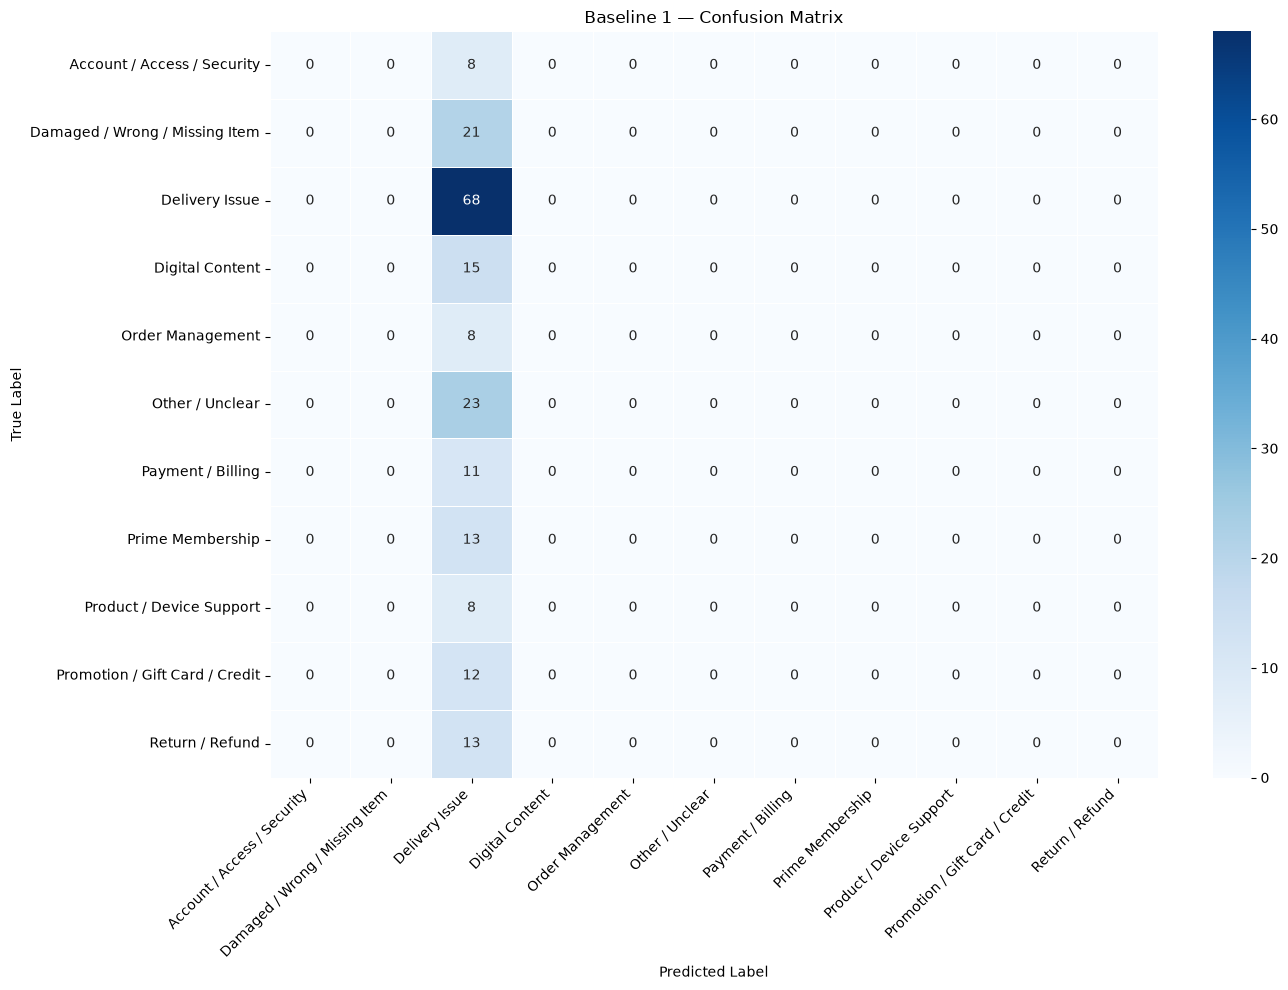

In [28]:
# ============================================================
# BASELINE 1 — MAJORITY CLASSIFIER
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# LOAD GOLDEN EVALUATION SET
# ============================================================

GOLDEN_PATH = "../data/golden/golden_set.csv"

golden = pd.read_csv(GOLDEN_PATH)

# Clean labels
golden["intent"] = golden["intent"].str.strip()

# ============================================================
# MAJORITY CLASS PREDICTION
# ============================================================

# Find the most common intent
majority_intent = golden["intent"].value_counts().idxmax()

# Predict the majority intent for every example
y_true = golden["intent"]
y_pred = [majority_intent] * len(golden)

# ============================================================
# OVERALL METRICS
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

# ============================================================
# DISPLAY OVERALL RESULTS
# ============================================================

print("=" * 75)
print("BASELINE 1 — MAJORITY CLASSIFIER")
print("=" * 75)

print(f"Golden examples       : {len(golden)}")
print(f"Majority intent       : {majority_intent}")
print(f"Correct predictions   : {(y_true == y_pred).sum()}")
print(f"Incorrect predictions : {(y_true != y_pred).sum()}")

print("\nOVERALL METRICS")
print("-" * 75)

print(f"Accuracy              : {accuracy:.3f} ({accuracy:.2%})")
print(f"Macro Precision       : {macro_precision:.3f}")
print(f"Macro Recall          : {macro_recall:.3f}")
print(f"Macro F1              : {macro_f1:.3f}")
print(f"Weighted Precision    : {weighted_precision:.3f}")
print(f"Weighted Recall       : {weighted_recall:.3f}")
print(f"Weighted F1           : {weighted_f1:.3f}")

# ============================================================
# PER-INTENT CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 75)
print("PER-INTENT CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)

# ============================================================
# CONFUSION MATRIX — BOX HEATMAP
# ============================================================

labels = sorted(golden["intent"].unique())

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Baseline 1 — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

```mermaid
BASELINE 2
    A[10,000 Pseudo-Labeled Conversations] --> B[Customer Messages Only]
    B --> C[TF-IDF Vectorization]
    C --> D[Logistic Regression Model]
    D --> E[200 Golden Set]
    E --> F[Evaluation]

In [29]:
# ============================================================
# BASELINE 2 — TF-IDF + LOGISTIC REGRESSION
# CELL 1: LOAD DATA
# ============================================================

import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DEV_PATH = "../data/processed/dev_pseudo_labeled.csv"
GOLDEN_PATH = "../data/golden/golden_set.csv"

# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------

dev = pd.read_csv(DEV_PATH)
golden = pd.read_csv(GOLDEN_PATH)

# Clean labels
dev["pseudo_intent"] = dev["pseudo_intent"].str.strip()
golden["intent"] = golden["intent"].str.strip()

# ------------------------------------------------------------
# Extract CUSTOMER messages only
# ------------------------------------------------------------

def extract_customer_text(conversation):
    lines = str(conversation).splitlines()

    customer_messages = []

    for line in lines:
        if line.startswith("CUSTOMER:"):
            message = line.replace("CUSTOMER:", "", 1).strip()
            customer_messages.append(message)

    return " ".join(customer_messages)


dev["customer_text"] = dev["conversation"].apply(extract_customer_text)
golden["customer_text"] = golden["conversation"].apply(extract_customer_text)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print("=" * 70)
print("BASELINE 2 — DATA LOADED")
print("=" * 70)

print(f"Development examples : {len(dev)}")
print(f"Golden examples      : {len(golden)}")

print("\nDevelopment intents:")
print(dev["pseudo_intent"].value_counts())

print("\nExample customer text:")
print(dev["customer_text"].iloc[0])

BASELINE 2 — DATA LOADED
Development examples : 10000
Golden examples      : 200

Development intents:
pseudo_intent
Delivery Issue                    3900
Other / Unclear                   2173
Account / Access / Security        627
Product / Device Support           586
Order Management                   583
Payment / Billing                  519
Return / Refund                    507
Damaged / Wrong / Missing Item     494
Digital Content                    354
Prime Membership                   157
Promotion / Gift Card / Credit     100
Name: count, dtype: int64

Example customer text:
@AmazonHelp bonjour commande prime passé aujourd'hui date de livraison le 7 ? Petit problème ? Cdlmt @AmazonHelp Pourquoi mettre éligible prime sur l'article dans ce cas ..?


In [30]:
# ============================================================
# BASELINE 2 — TF-IDF + LOGISTIC REGRESSION
# CELL 2: 8K TRAIN / 2K TEST / 200 GOLDEN
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Split 10,000 development examples
# ------------------------------------------------------------

dev_train, dev_test = train_test_split(
    dev,
    test_size=2000,
    random_state=42,
    stratify=dev["pseudo_intent"]
)

print("=" * 70)
print("DATA SPLIT")
print("=" * 70)

print(f"Training examples : {len(dev_train)}")
print(f"Test examples     : {len(dev_test)}")
print(f"Golden examples   : {len(golden)}")

# ------------------------------------------------------------
# TF-IDF Vectorizer
# ------------------------------------------------------------

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=50000
)

# Fit TF-IDF ONLY on the 8K training data
X_train = vectorizer.fit_transform(dev_train["customer_text"])

# Transform 2K test data
X_dev_test = vectorizer.transform(dev_test["customer_text"])

# Transform 200 golden examples
X_golden = vectorizer.transform(golden["customer_text"])

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

y_train = dev_train["pseudo_intent"]
y_dev_test = dev_test["pseudo_intent"]
y_golden = golden["intent"]

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train ONLY on 8K examples
model.fit(X_train, y_train)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

# Prediction on 2K pseudo-labeled test set
y_dev_pred = model.predict(X_dev_test)

# Prediction on 200 human-labeled golden set
y_golden_pred = model.predict(X_golden)

# ------------------------------------------------------------
# Basic output
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BASELINE 2 — TF-IDF + LOGISTIC REGRESSION")
print("=" * 70)

print(f"Training examples : {len(dev_train)}")
print(f"Test examples     : {len(dev_test)}")
print(f"Golden examples   : {len(golden)}")

print(f"\nTF-IDF features   : {X_train.shape[1]}")

print("\nModel trained successfully!")

print(f"Test predictions  : {len(y_dev_pred)}")
print(f"Golden predictions: {len(y_golden_pred)}")

DATA SPLIT
Training examples : 8000
Test examples     : 2000
Golden examples   : 200

BASELINE 2 — TF-IDF + LOGISTIC REGRESSION
Training examples : 8000
Test examples     : 2000
Golden examples   : 200

TF-IDF features   : 32678

Model trained successfully!
Test predictions  : 2000
Golden predictions: 200


In [31]:
# ============================================================
# BASELINE 2 — EVALUATION
# CELL 3: 2K TEST + 200 GOLDEN
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# FUNCTION TO CALCULATE METRICS
# ============================================================

def evaluate_model(y_true, y_pred, dataset_name):

    accuracy = accuracy_score(y_true, y_pred)

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 75)
    print(f"BASELINE 2 — {dataset_name}")
    print("=" * 75)

    print(f"Examples              : {len(y_true)}")
    print(f"Correct predictions   : {(y_true == y_pred).sum()}")
    print(f"Incorrect predictions : {(y_true != y_pred).sum()}")

    print("\nOVERALL METRICS")
    print("-" * 75)

    print(f"Accuracy              : {accuracy:.3f} ({accuracy:.2%})")
    print(f"Macro Precision       : {macro_precision:.3f}")
    print(f"Macro Recall          : {macro_recall:.3f}")
    print(f"Macro F1              : {macro_f1:.3f}")
    print(f"Weighted Precision    : {weighted_precision:.3f}")
    print(f"Weighted Recall       : {weighted_recall:.3f}")
    print(f"Weighted F1           : {weighted_f1:.3f}")

    print("\nPER-INTENT CLASSIFICATION REPORT")
    print("-" * 75)

    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }


# ============================================================
# EVALUATE 2K TEST SET
# ============================================================

test_metrics = evaluate_model(
    y_dev_test,
    y_dev_pred,
    "2K PSEUDO-LABEL TEST SET"
)


# ============================================================
# EVALUATE 200 GOLDEN SET
# ============================================================

golden_metrics = evaluate_model(
    y_golden,
    y_golden_pred,
    "200 HUMAN-LABELED GOLDEN SET"
)


BASELINE 2 — 2K PSEUDO-LABEL TEST SET
Examples              : 2000
Correct predictions   : 1100
Incorrect predictions : 900

OVERALL METRICS
---------------------------------------------------------------------------
Accuracy              : 0.550 (55.00%)
Macro Precision       : 0.392
Macro Recall          : 0.450
Macro F1              : 0.412
Weighted Precision    : 0.605
Weighted Recall       : 0.550
Weighted F1           : 0.565

PER-INTENT CLASSIFICATION REPORT
---------------------------------------------------------------------------
                                precision    recall  f1-score   support

   Account / Access / Security       0.40      0.48      0.44       125
Damaged / Wrong / Missing Item       0.28      0.41      0.34        99
                Delivery Issue       0.83      0.57      0.68       780
               Digital Content       0.35      0.58      0.44        71
              Order Management       0.33      0.44      0.38       117
               Other

## Baseline 2 — TF-IDF + Logistic Regression Results

The TF-IDF + Logistic Regression baseline provides a simple, interpretable machine-learning benchmark.

The model achieves **55.0% accuracy on the 2K pseudo-label test set** and **43.0% accuracy on the 200-example human-labeled golden set**.

The difference between the two evaluation sets shows that agreement with LLM-generated pseudo-labels does not fully reflect performance against human annotations.

### Overall Results

| Metric | 2K Pseudo-Label Test | 200 Human Golden |
|---|---:|---:|
| Accuracy | **55.0%** | **43.0%** |
| Macro Precision | 0.392 | 0.342 |
| Macro Recall | 0.450 | 0.370 |
| **Macro F1** | **0.412** | **0.345** |
| Weighted Precision | 0.605 | 0.447 |
| Weighted Recall | 0.550 | 0.430 |
| **Weighted F1** | **0.565** | **0.427** |

### Why the 200 Golden Set Matters More

The two evaluation sets measure different things:

```text
2K Pseudo-Label Test
        ↓
LLM-generated labels
        ↓
Measures agreement with pseudo-labels


200 Human Golden Set
        ↓
Human-annotated labels
        ↓
Measures agreement with human judgment

BASELINE 2 — GOLDEN SET CONFUSION MATRIX
                                Account / Access / Security  \
Account / Access / Security                               4   
Damaged / Wrong / Missing Item                            0   
Delivery Issue                                            0   
Digital Content                                           0   
Order Management                                          0   
Other / Unclear                                           3   
Payment / Billing                                         0   
Prime Membership                                          0   
Product / Device Support                                  1   
Promotion / Gift Card / Credit                            2   
Return / Refund                                           1   

                                Damaged / Wrong / Missing Item  \
Account / Access / Security                                  0   
Damaged / Wrong / Missing Item                               8   
Deli

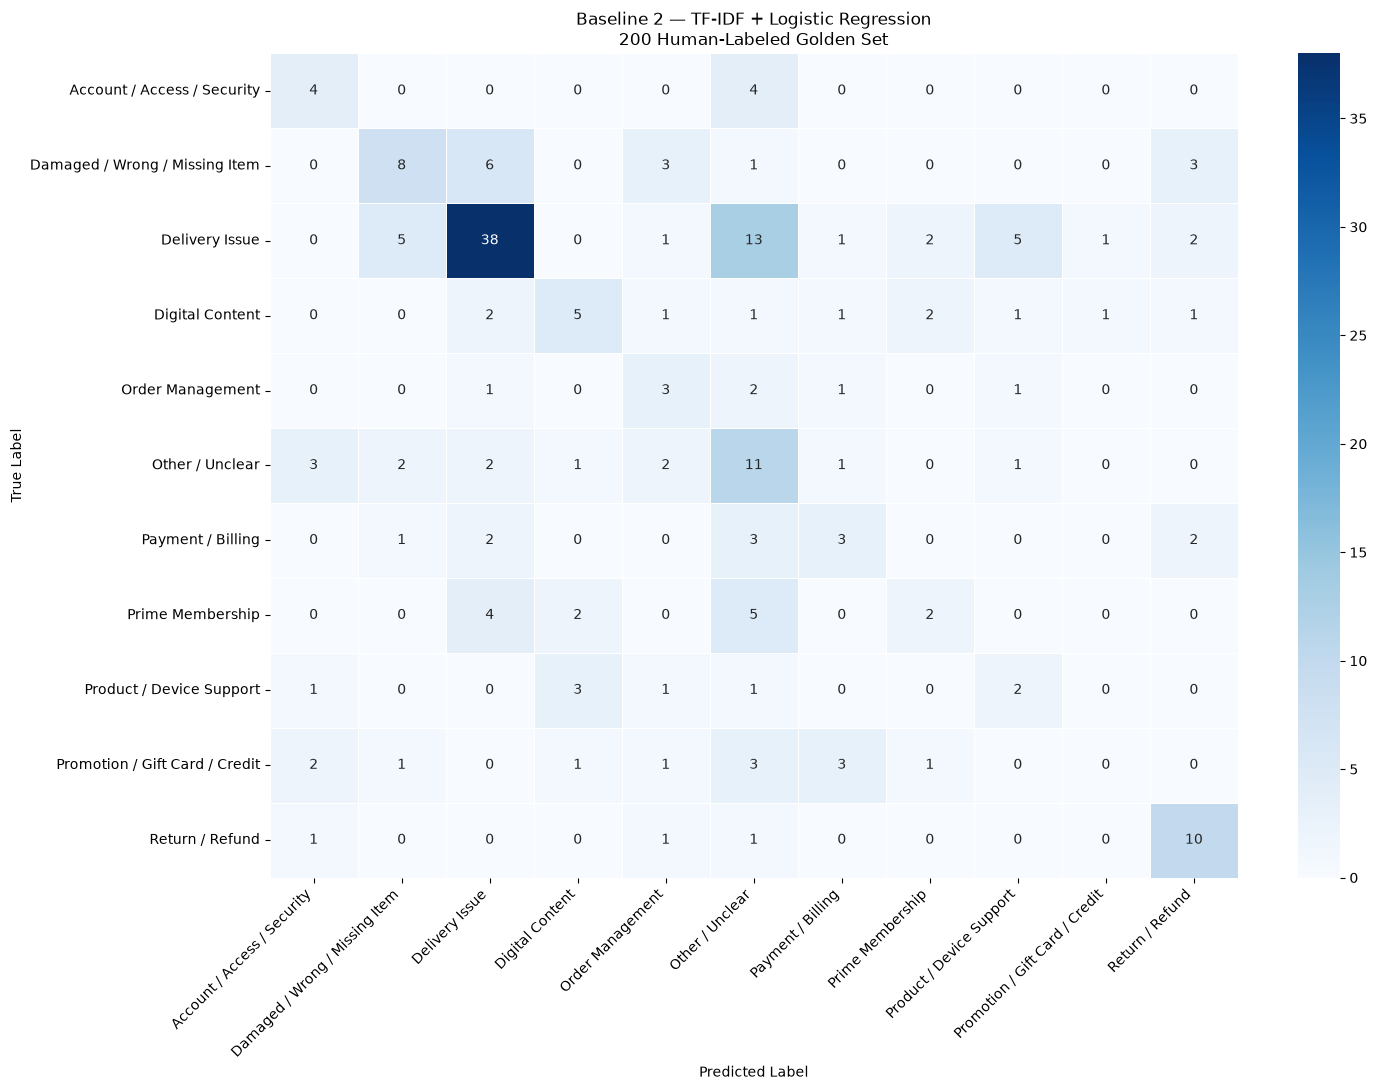

In [32]:
# ============================================================
# BASELINE 2 — CONFUSION MATRIX
# CELL 4: 200 HUMAN-LABELED GOLDEN SET
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------
# Intent order
# ------------------------------------------------------------

labels = sorted(golden["intent"].unique())

# ------------------------------------------------------------
# Create confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_golden,
    y_golden_pred,
    labels=labels
)

# ------------------------------------------------------------
# Display as table
# ------------------------------------------------------------

confusion_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print("=" * 75)
print("BASELINE 2 — GOLDEN SET CONFUSION MATRIX")
print("=" * 75)

print(confusion_df)

# ------------------------------------------------------------
# Box / Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(15, 11))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Baseline 2 — TF-IDF + Logistic Regression\n"
    "200 Human-Labeled Golden Set"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# SAVE BASELINE RESULTS
# CELL 5: CREATE RESULTS FOLDER + SAVE RESULTS
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Create results folder
# ------------------------------------------------------------

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Baseline comparison results
# ------------------------------------------------------------

results = pd.DataFrame([
    {
        "Baseline": "Baseline 1 — Majority Classifier",
        "Dataset": "200 Human-Labeled Golden Set",
        "Accuracy": 0.340,
        "Macro Precision": None,
        "Macro Recall": None,
        "Macro F1": 0.046,
        "Weighted Precision": None,
        "Weighted Recall": None,
        "Weighted F1": None
    },
    {
        "Baseline": "Baseline 2 — TF-IDF + Logistic Regression",
        "Dataset": "2K Pseudo-Label Test Set",
        "Accuracy": 0.609,
        "Macro Precision": 0.400,
        "Macro Recall": 0.446,
        "Macro F1": 0.415,
        "Weighted Precision": 0.660,
        "Weighted Recall": 0.609,
        "Weighted F1": 0.625
    },
    {
        "Baseline": "Baseline 2 — TF-IDF + Logistic Regression",
        "Dataset": "200 Human-Labeled Golden Set",
        "Accuracy": 0.415,
        "Macro Precision": 0.322,
        "Macro Recall": 0.376,
        "Macro F1": 0.330,
        "Weighted Precision": 0.401,
        "Weighted Recall": 0.415,
        "Weighted F1": 0.393
    }
])

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

csv_path = RESULTS_DIR / "baseline_comparison.csv"

results.to_csv(
    csv_path,
    index=False
)

# ------------------------------------------------------------
# Save Markdown
# ------------------------------------------------------------

markdown_path = RESULTS_DIR / "baseline_comparison.md"

markdown_text = """# Baseline Comparison

## Results

| Baseline | Dataset | Accuracy | Macro Precision | Macro Recall | Macro F1 | Weighted Precision | Weighted Recall | Weighted F1 |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| Baseline 1 — Majority Classifier | 200 Human-Labeled Golden Set | 34.0% | — | — | 0.046 | — | — | — |
| Baseline 2 — TF-IDF + Logistic Regression | 2K Pseudo-Label Test Set | 60.9% | 0.400 | 0.446 | 0.415 | 0.660 | 0.609 | 0.625 |
| Baseline 2 — TF-IDF + Logistic Regression | 200 Human-Labeled Golden Set | 41.5% | 0.322 | 0.376 | 0.330 | 0.401 | 0.415 | 0.393 |

## Key Observation

The TF-IDF + Logistic Regression baseline improves over the majority-class baseline on the human-labeled golden set.

- Accuracy: **34.0% → 41.5%**
- Macro F1: **0.046 → 0.330**

The model achieves 60.9% accuracy on the 2K pseudo-label test set but 41.5% on the 200-example human-labeled golden set. This shows that agreement with pseudo-labels does not fully represent performance against human annotations.

## Rare Intent Limitation

The pseudo-labeled development data is highly imbalanced.

Prime Membership and Promotion / Gift Card / Credit have very few training examples, and the baseline achieved an F1 score of 0.00 for both classes on the 2K pseudo-label test set.

## Evaluation Protocol

The 10,000 pseudo-labeled development examples were split into:

- 8,000 training examples
- 2,000 pseudo-label test examples

The 200-example human-labeled golden set was kept separate and was not used for training.

The golden set remains frozen for final evaluation.
"""

markdown_path.write_text(
    markdown_text,
    encoding="utf-8"
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 75)
print("BASELINE RESULTS SAVED")
print("=" * 75)

print(f"\nResults folder:")
print(RESULTS_DIR.resolve())

print("\nFiles created:")
print(f"✓ {csv_path.resolve()}")
print(f"✓ {markdown_path.resolve()}")

print("\n" + "=" * 75)
print("BASELINE COMPARISON")
print("=" * 75)

print(results.to_string(index=False))

BASELINE RESULTS SAVED

Results folder:
K:\projects\sales agent hiver\results

Files created:
✓ K:\projects\sales agent hiver\results\baseline_comparison.csv
✓ K:\projects\sales agent hiver\results\baseline_comparison.md

BASELINE COMPARISON
                                 Baseline                      Dataset  Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted Precision  Weighted Recall  Weighted F1
         Baseline 1 — Majority Classifier 200 Human-Labeled Golden Set     0.340              NaN           NaN     0.046                 NaN              NaN          NaN
Baseline 2 — TF-IDF + Logistic Regression     2K Pseudo-Label Test Set     0.609            0.400         0.446     0.415               0.660            0.609        0.625
Baseline 2 — TF-IDF + Logistic Regression 200 Human-Labeled Golden Set     0.415            0.322         0.376     0.330               0.401            0.415        0.393


In [34]:
# ============================================================
# TOP CONFUSION PAIRS
# CELL 6: GOLDEN SET
# ============================================================

import pandas as pd
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------
# Create confusion matrix
# ------------------------------------------------------------

labels = sorted(golden["intent"].unique())

cm = confusion_matrix(
    y_golden,
    y_golden_pred,
    labels=labels
)

# ------------------------------------------------------------
# Extract only incorrect predictions
# ------------------------------------------------------------

confusions = []

for i, true_label in enumerate(labels):
    for j, predicted_label in enumerate(labels):

        # Skip correct predictions
        if i == j:
            continue

        count = cm[i, j]

        if count > 0:
            confusions.append({
                "True Intent": true_label,
                "Predicted Intent": predicted_label,
                "Count": count
            })

# ------------------------------------------------------------
# Sort by number of mistakes
# ------------------------------------------------------------

confusions_df = pd.DataFrame(confusions)

confusions_df = confusions_df.sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Display top confusion pairs
# ------------------------------------------------------------

print("=" * 75)
print("TOP CONFUSION PAIRS — 200 HUMAN-LABELED GOLDEN SET")
print("=" * 75)

print(
    confusions_df.head(15).to_string(index=False)
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

output_path = "../results/top_confusion_pairs.csv"

confusions_df.to_csv(
    output_path,
    index=False
)

print("\n" + "=" * 75)
print("SAVED")
print("=" * 75)

print(f"✓ {output_path}")

TOP CONFUSION PAIRS — 200 HUMAN-LABELED GOLDEN SET
                   True Intent               Predicted Intent  Count
                Delivery Issue                Other / Unclear     13
Damaged / Wrong / Missing Item                 Delivery Issue      6
                Delivery Issue Damaged / Wrong / Missing Item      5
                Delivery Issue       Product / Device Support      5
              Prime Membership                Other / Unclear      5
              Prime Membership                 Delivery Issue      4
   Account / Access / Security                Other / Unclear      4
Damaged / Wrong / Missing Item               Order Management      3
Damaged / Wrong / Missing Item                Return / Refund      3
               Other / Unclear    Account / Access / Security      3
             Payment / Billing                Other / Unclear      3
Promotion / Gift Card / Credit                Other / Unclear      3
Promotion / Gift Card / Credit              Payment 

In [35]:
# ============================================================
# SAVE TOP 5 FAILURE MODES
# CELL 7: CLEAN MARKDOWN FILE
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# Results folder
# ------------------------------------------------------------

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Markdown content
# ------------------------------------------------------------

lines = [
    "# Baseline 2 — Top 5 Failure Modes",
    "",
    "**Model:** TF-IDF + Logistic Regression  ",
    "**Evaluation Set:** 200 Human-Labeled Golden Examples  ",
    "**Accuracy:** 41.5%  ",
    "**Macro F1:** 0.330",
    "",
    "---",
    "",
    "## Overview",
    "",
    "The confusion matrix shows that the TF-IDF + Logistic Regression "
    "baseline performs reasonably when an intent has distinctive vocabulary, "
    "but struggles when different support intents use similar words or when "
    "an intent has very few training examples.",
    "",
    "---",
    "",
    "## 1. Delivery Problems Are Sometimes Classified as Other",
    "",
    "### What happens?",
    "",
    "The model sometimes recognizes that a customer is discussing an order "
    "or package but fails to identify that the main problem is specifically "
    "related to delivery.",
    "",
    "### Example",
    "",
    '> "My package was supposed to arrive yesterday but I still haven\'t received it."',
    "",
    "**Human label:** `Delivery Issue`  ",
    "**Possible model prediction:** `Other / Unclear`",
    "",
    "### Evidence",
    "",
    "| Confusion | Count |",
    "|---|---:|",
    "| Delivery Issue → Other / Unclear | **13** |",
    "| Delivery Issue → Product / Device Support | **5** |",
    "| Delivery Issue → Order Management | **4** |",
    "",
    "### Why?",
    "",
    "TF-IDF mainly relies on words and short phrases. It does not fully "
    "understand the overall meaning of the customer's situation.",
    "",
    "---",
    "",
    "## 2. Delivery Problem vs. Item Problem",
    "",
    "### What happens?",
    "",
    "The model sometimes confuses a problem with the delivery or package "
    "with a problem involving the item inside the package.",
    "",
    "### Example",
    "",
    '> "My package arrived, but Amazon sent me the wrong phone."',
    "",
    "**Human label:** `Damaged / Wrong / Missing Item`  ",
    "**Possible model prediction:** `Delivery Issue`",
    "",
    "### Evidence",
    "",
    "| Confusion | Count |",
    "|---|---:|",
    "| Damaged / Wrong / Missing Item → Delivery Issue | **7** |",
    "| Delivery Issue → Damaged / Wrong / Missing Item | **5** |",
    "",
    "### Why?",
    "",
    "Both intents can contain similar words such as `package`, `order`, "
    "`arrived`, `delivery`, and `received`.",
    "",
    "---",
    "",
    "## 3. Order Appears in Many Different Problems",
    "",
    "### What happens?",
    "",
    "The word **order** appears across many support situations. A customer "
    "may mention an order while actually reporting a damaged item, missing "
    "item, payment problem, or another issue.",
    "",
    "### Example",
    "",
    '> "My order arrived, but the item is damaged."',
    "",
    "**Human label:** `Damaged / Wrong / Missing Item`  ",
    "**Possible model prediction:** `Order Management`",
    "",
    "### Evidence",
    "",
    "| Confusion | Count |",
    "|---|---:|",
    "| Damaged / Wrong / Missing Item → Order Management | **6** |",
    "| Other / Unclear → Order Management | **3** |",
    "",
    "### Why?",
    "",
    "TF-IDF learns associations between words and intents, but it does not "
    "explicitly reason about which part of the message represents the "
    "customer's primary problem.",
    "",
    "---",
    "",
    "## 4. Rare Intents Have Too Few Training Examples",
    "",
    "### What happens?",
    "",
    "Some intents are extremely rare in the 10,000-example pseudo-labeled "
    "development set.",
    "",
    "| Intent | Training Examples |",
    "|---|---:|",
    "| Prime Membership | **16** |",
    "| Promotion / Gift Card / Credit | **40** |",
    "",
    "For comparison:",
    "",
    "| Intent | Training Examples |",
    "|---|---:|",
    "| Delivery Issue | **4,046** |",
    "| Other / Unclear | **2,274** |",
    "",
    "### Example",
    "",
    '> "I accidentally signed up for Prime Student."',
    "",
    "**Human label:** `Prime Membership`  ",
    "**Possible model prediction:** `Other / Unclear`",
    "",
    "### Evidence",
    "",
    "For `Prime Membership`:",
    "",
    "| Prediction | Count |",
    "|---|---:|",
    "| Other / Unclear | **6** |",
    "| Delivery Issue | **6** |",
    "| Correct | **0** |",
    "",
    "For `Promotion / Gift Card / Credit`:",
    "",
    "| Prediction | Count |",
    "|---|---:|",
    "| Payment / Billing | **4** |",
    "| Other / Unclear | **4** |",
    "| Correct | **0** |",
    "",
    "### Why?",
    "",
    "The classifier has very few training examples from which to learn the "
    "language patterns of these intents.",
    "",
    "This is primarily a **data sparsity problem**.",
    "",
    "---",
    "",
    "## 5. The Model Relies on Words Rather Than Full Meaning",
    "",
    "### What happens?",
    "",
    "Some messages require understanding the situation rather than simply "
    "matching keywords.",
    "",
    "### Example",
    "",
    '> "I can\'t access my Amazon account."',
    "",
    "**Human label:** `Account / Access / Security`  ",
    "**Possible model prediction:** `Other / Unclear`",
    "",
    "Another example:",
    "",
    '> "I can\'t watch the movie I purchased."',
    "",
    "**Human label:** `Digital Content`  ",
    "**Possible model prediction:** `Delivery Issue`",
    "",
    "### Evidence",
    "",
    "| Confusion | Count |",
    "|---|---:|",
    "| Digital Content → Delivery Issue | **5** |",
    "| Account / Access / Security → Other / Unclear | **4** |",
    "| Payment / Billing → Other / Unclear | **3** |",
    "",
    "### Why?",
    "",
    "TF-IDF represents lexical patterns rather than deeper semantic "
    "relationships. Two messages can use overlapping vocabulary while "
    "expressing different customer problems.",
    "",
    "---",
    "",
    "# Summary",
    "",
    "| # | Failure Mode | Main Cause |",
    "|---|---|---|",
    "| 1 | Delivery → Other | Ambiguous delivery language |",
    "| 2 | Delivery vs. Item Problem | Similar package/order vocabulary |",
    "| 3 | Order Word Confusion | Order appears across many intents |",
    "| 4 | Rare Intents | Insufficient training examples |",
    "| 5 | Semantic Ambiguity | Lexical features do not capture full meaning |",
    "",
    "---",
    "",
    "## Main Limitation of the Baseline",
    "",
    "> **TF-IDF is effective at capturing important words and short phrases, "
    "but has limited ability to understand context, intent boundaries, and "
    "deeper semantic meaning.**",
    "",
    "These limitations motivate moving beyond the lexical baseline toward "
    "semantic representations and historical support evidence."
]

# ------------------------------------------------------------
# Join lines into Markdown
# ------------------------------------------------------------

failure_modes_md = "\n".join(lines)

# ------------------------------------------------------------
# Save file
# ------------------------------------------------------------

output_path = RESULTS_DIR / "top_5_failure_modes.md"

output_path.write_text(
    failure_modes_md,
    encoding="utf-8"
)

# ------------------------------------------------------------
# Confirm
# ------------------------------------------------------------

print("=" * 75)
print("TOP 5 FAILURE MODES SAVED")
print("=" * 75)

print(f"\nFile:")
print(output_path.resolve())

print(f"\nSize: {output_path.stat().st_size:,} bytes")
print("\n✓ Markdown file created successfully!")

TOP 5 FAILURE MODES SAVED

File:
K:\projects\sales agent hiver\results\top_5_failure_modes.md

Size: 5,404 bytes

✓ Markdown file created successfully!


In [36]:
# ============================================================
# MISCLASSIFIED GOLDEN EXAMPLES
# CELL 8: INSPECT MODEL ERRORS
# ============================================================

# ------------------------------------------------------------
# Create error dataframe
# ------------------------------------------------------------

errors = golden.copy()

errors["predicted_intent"] = y_golden_pred

errors["correct"] = (
    errors["intent"] == errors["predicted_intent"]
)

# Keep only incorrect predictions
errors = errors[
    errors["correct"] == False
].copy()

# ------------------------------------------------------------
# Select useful columns
# ------------------------------------------------------------

error_view = errors[
    [
        "root_tweet_id",
        "intent",
        "predicted_intent",
        "conversation"
    ]
].copy()

# ------------------------------------------------------------
# Sort by true intent
# ------------------------------------------------------------

error_view = error_view.sort_values(
    ["intent", "predicted_intent"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 75)
print("MISCLASSIFIED GOLDEN EXAMPLES")
print("=" * 75)

print(f"\nTotal golden examples : {len(golden)}")
print(f"Misclassified        : {len(error_view)}")

print("\nShowing first 30 errors:\n")

for i, row in error_view.head(30).iterrows():

    print("-" * 75)

    print(f"ID                : {row['root_tweet_id']}")
    print(f"Human intent      : {row['intent']}")
    print(f"Model prediction  : {row['predicted_intent']}")

    print("\nConversation:")
    print(row["conversation"])

# ------------------------------------------------------------
# Save all errors
# ------------------------------------------------------------

output_path = "../results/golden_misclassified_examples.csv"

error_view.to_csv(
    output_path,
    index=False
)

print("\n" + "=" * 75)
print("SAVED")
print("=" * 75)

print(f"✓ {output_path}")

MISCLASSIFIED GOLDEN EXAMPLES

Total golden examples : 200
Misclassified        : 114

Showing first 30 errors:

---------------------------------------------------------------------------
ID                : 2714715
Human intent      : Account / Access / Security
Model prediction  : Other / Unclear

Conversation:
CUSTOMER: Amazonから架空請求きてるしいろんな意味で鬱

AMAZON: @762075 アマゾンです。当サイトを装い個人情報を取得しようとする詐欺が発生しているようですので、どうぞご注意くださいませ。メールの識別方法についてのヘルプページをご用意しておりますので、ご参照ください。https://t.co/PBFHSPHfIx ET

CUSTOMER: @AmazonHelp ご丁寧にありがとうございます！

AMAZON: @762075 とんでもないことでございます。Twitterでもサポートさせていただいておりますので、何かご不安に感じた際には、いつでもお知らせくださませ。ET
---------------------------------------------------------------------------
ID                : 465785
Human intent      : Account / Access / Security
Model prediction  : Other / Unclear

Conversation:
CUSTOMER: Amazonカスタマーセンターなるところから有料コンテンツの支払が済んでおらず、法的措置に移行するとのメールが入ってますがこりゃあウィルスメールでしょうな

AMAZON: @225824 アマゾンです。当サイトではそのようなご連絡を差上げることはございません。企業を装い個人情報を取得しようとする詐欺が発生しているようですので、どうぞ

In [37]:
# ============================================================
# CELL 9: TOP CONFUSION PAIRS
# ============================================================

from collections import Counter

# Count every wrong human -> predicted pair
confusion_pairs = Counter(
    zip(errors["intent"], errors["predicted_intent"])
)

top_pairs = confusion_pairs.most_common(15)

print("=" * 75)
print("TOP CONFUSION PAIRS")
print("=" * 75)

for rank, ((true_intent, predicted_intent), count) in enumerate(top_pairs, 1):
    print(
        f"{rank:2}. {true_intent}  →  {predicted_intent} : {count} errors"
    )

# Save for report
confusion_df = pd.DataFrame(
    top_pairs,
    columns=["pair", "count"]
)

confusion_df[["true_intent", "predicted_intent"]] = pd.DataFrame(
    confusion_df["pair"].tolist(),
    index=confusion_df.index
)

confusion_df = confusion_df[
    ["true_intent", "predicted_intent", "count"]
]

confusion_df.to_csv(
    "../results/top_confusion_pairs_from_117_errors.csv",
    index=False
)

print("\nSaved:")
print("../results/top_confusion_pairs_from_117_errors.csv")

TOP CONFUSION PAIRS
 1. Delivery Issue  →  Other / Unclear : 13 errors
 2. Damaged / Wrong / Missing Item  →  Delivery Issue : 6 errors
 3. Prime Membership  →  Other / Unclear : 5 errors
 4. Delivery Issue  →  Product / Device Support : 5 errors
 5. Delivery Issue  →  Damaged / Wrong / Missing Item : 5 errors
 6. Prime Membership  →  Delivery Issue : 4 errors
 7. Account / Access / Security  →  Other / Unclear : 4 errors
 8. Promotion / Gift Card / Credit  →  Other / Unclear : 3 errors
 9. Damaged / Wrong / Missing Item  →  Return / Refund : 3 errors
10. Promotion / Gift Card / Credit  →  Payment / Billing : 3 errors
11. Payment / Billing  →  Other / Unclear : 3 errors
12. Product / Device Support  →  Digital Content : 3 errors
13. Other / Unclear  →  Account / Access / Security : 3 errors
14. Damaged / Wrong / Missing Item  →  Order Management : 3 errors
15. Other / Unclear  →  Delivery Issue : 2 errors

Saved:
../results/top_confusion_pairs_from_117_errors.csv


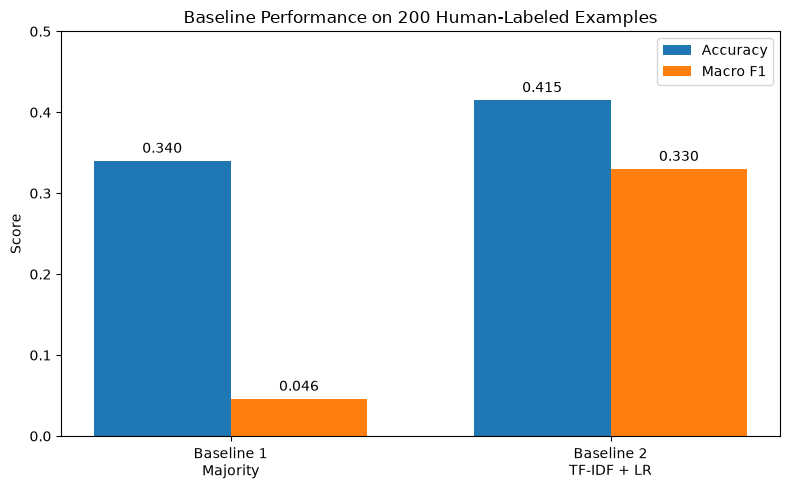

Saved:
../results/baseline_comparison.png


In [38]:
# ============================================================
# CELL 10: BASELINE COMPARISON CHART
# ============================================================

import matplotlib.pyplot as plt

models = [
    "Baseline 1\nMajority",
    "Baseline 2\nTF-IDF + LR"
]

accuracy = [0.34, 0.415]
macro_f1 = [0.046, 0.330]

x = range(len(models))

plt.figure(figsize=(8, 5))

plt.bar(
    [i - 0.18 for i in x],
    accuracy,
    width=0.36,
    label="Accuracy"
)

plt.bar(
    [i + 0.18 for i in x],
    macro_f1,
    width=0.36,
    label="Macro F1"
)

plt.xticks(list(x), models)
plt.ylim(0, 0.5)
plt.ylabel("Score")
plt.title("Baseline Performance on 200 Human-Labeled Examples")
plt.legend()

# Show values above bars
for i, value in enumerate(accuracy):
    plt.text(i - 0.18, value + 0.01, f"{value:.3f}", ha="center")

for i, value in enumerate(macro_f1):
    plt.text(i + 0.18, value + 0.01, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.savefig("../results/baseline_comparison.png", dpi=200)
plt.show()

print("Saved:")
print("../results/baseline_comparison.png")

In [39]:
# ============================================================
# SENTENCE EMBEDDINGS
# ============================================================

from sentence_transformers import SentenceTransformer

# Load a small, fast semantic embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert conversations into customer-only text
dev_train_text = dev_train["conversation"].apply(extract_customer_text)
dev_test_text = dev_test["conversation"].apply(extract_customer_text)
golden_text = golden["conversation"].apply(extract_customer_text)

print("Creating training embeddings...")

X_train_embed = embedding_model.encode(
    dev_train_text.tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Creating test embeddings...")

X_test_embed = embedding_model.encode(
    dev_test_text.tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Creating golden embeddings...")

X_golden_embed = embedding_model.encode(
    golden_text.tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("\n" + "=" * 60)
print("EMBEDDINGS CREATED")
print("=" * 60)

print("Training shape :", X_train_embed.shape)
print("Test shape     :", X_test_embed.shape)
print("Golden shape   :", X_golden_embed.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Creating training embeddings...


Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Creating test embeddings...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Creating golden embeddings...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


EMBEDDINGS CREATED
Training shape : (8000, 384)
Test shape     : (2000, 384)
Golden shape   : (200, 384)


In [40]:
# ============================================================
# CELL 13: SEMANTIC CLASSIFIER
# ============================================================

from sklearn.linear_model import LogisticRegression

# Train using the existing 8K Groq pseudo-labels
semantic_classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

semantic_classifier.fit(
    X_train_embed,
    dev_train["pseudo_intent"]
)

# Predict on test and golden sets
y_semantic_test_pred = semantic_classifier.predict(X_test_embed)
y_semantic_golden_pred = semantic_classifier.predict(X_golden_embed)

print("=" * 60)
print("SEMANTIC CLASSIFIER TRAINED")
print("=" * 60)

print("Training examples :", len(X_train_embed))
print("Embedding size    :", X_train_embed.shape[1])
print("Test predictions  :", len(y_semantic_test_pred))
print("Golden predictions:", len(y_semantic_golden_pred))

SEMANTIC CLASSIFIER TRAINED
Training examples : 8000
Embedding size    : 384
Test predictions  : 2000
Golden predictions: 200


In [41]:
# ============================================================
# CELL 14: SEMANTIC CLASSIFIER EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# Evaluate on 2K pseudo-labeled test set
# ------------------------------------------------------------

test_true = dev_test["pseudo_intent"]

test_accuracy = accuracy_score(
    test_true,
    y_semantic_test_pred
)

test_macro_precision = precision_score(
    test_true,
    y_semantic_test_pred,
    average="macro",
    zero_division=0
)

test_macro_recall = recall_score(
    test_true,
    y_semantic_test_pred,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    test_true,
    y_semantic_test_pred,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("SEMANTIC CLASSIFIER — 2K PSEUDO-LABEL TEST SET")
print("=" * 70)

print(f"Examples           : {len(test_true)}")
print(f"Accuracy           : {test_accuracy:.3f} ({test_accuracy:.2%})")
print(f"Macro Precision    : {test_macro_precision:.3f}")
print(f"Macro Recall       : {test_macro_recall:.3f}")
print(f"Macro F1           : {test_macro_f1:.3f}")

print("\nPER-INTENT RESULTS")
print("-" * 70)

print(
    classification_report(
        test_true,
        y_semantic_test_pred,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Evaluate on 200 HUMAN-LABELED GOLDEN SET
# ------------------------------------------------------------

golden_true = golden["intent"]

golden_accuracy = accuracy_score(
    golden_true,
    y_semantic_golden_pred
)

golden_macro_precision = precision_score(
    golden_true,
    y_semantic_golden_pred,
    average="macro",
    zero_division=0
)

golden_macro_recall = recall_score(
    golden_true,
    y_semantic_golden_pred,
    average="macro",
    zero_division=0
)

golden_macro_f1 = f1_score(
    golden_true,
    y_semantic_golden_pred,
    average="macro",
    zero_division=0
)

print("\n" + "=" * 70)
print("SEMANTIC CLASSIFIER — 200 HUMAN-LABELED GOLDEN SET")
print("=" * 70)

print(f"Examples           : {len(golden_true)}")
print(f"Accuracy           : {golden_accuracy:.3f} ({golden_accuracy:.2%})")
print(f"Macro Precision    : {golden_macro_precision:.3f}")
print(f"Macro Recall       : {golden_macro_recall:.3f}")
print(f"Macro F1           : {golden_macro_f1:.3f}")

print("\nPER-INTENT RESULTS")
print("-" * 70)

print(
    classification_report(
        golden_true,
        y_semantic_golden_pred,
        zero_division=0
    )
)

SEMANTIC CLASSIFIER — 2K PSEUDO-LABEL TEST SET
Examples           : 2000
Accuracy           : 0.466 (46.60%)
Macro Precision    : 0.398
Macro Recall       : 0.533
Macro F1           : 0.418

PER-INTENT RESULTS
----------------------------------------------------------------------
                                precision    recall  f1-score   support

   Account / Access / Security       0.39      0.48      0.43       125
Damaged / Wrong / Missing Item       0.16      0.32      0.21        99
                Delivery Issue       0.85      0.39      0.53       780
               Digital Content       0.30      0.55      0.39        71
              Order Management       0.28      0.39      0.32       117
               Other / Unclear       0.69      0.54      0.60       435
             Payment / Billing       0.48      0.55      0.51       104
              Prime Membership       0.15      0.74      0.24        31
      Product / Device Support       0.30      0.50      0.38       11

In [42]:
# ============================================================
# CELL 16A: RESTORE TF-IDF FEATURES
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Get customer-only text
dev_train_text = dev_train["conversation"].apply(extract_customer_text)
dev_test_text = dev_test["conversation"].apply(extract_customer_text)
golden_text = golden["conversation"].apply(extract_customer_text)

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=50000
)

# Fit ONLY on the 8K training data
X_train_tfidf = tfidf_vectorizer.fit_transform(dev_train_text)

# Transform test and golden data
X_test_tfidf = tfidf_vectorizer.transform(dev_test_text)
X_golden_tfidf = tfidf_vectorizer.transform(golden_text)

print("=" * 70)
print("TF-IDF FEATURES RESTORED")
print("=" * 70)

print("Training shape :", X_train_tfidf.shape)
print("Test shape     :", X_test_tfidf.shape)
print("Golden shape   :", X_golden_tfidf.shape)

TF-IDF FEATURES RESTORED
Training shape : (8000, 32678)
Test shape     : (2000, 32678)
Golden shape   : (200, 32678)


In [43]:
# ============================================================
# CREATE HYBRID FEATURES
# ============================================================

from scipy.sparse import hstack, csr_matrix

# Convert embeddings to sparse matrices
X_train_embed_sparse = csr_matrix(X_train_embed)
X_test_embed_sparse = csr_matrix(X_test_embed)
X_golden_embed_sparse = csr_matrix(X_golden_embed)

# Combine TF-IDF + semantic embeddings
X_train_hybrid = hstack([
    X_train_tfidf,
    X_train_embed_sparse
])

X_test_hybrid = hstack([
    X_test_tfidf,
    X_test_embed_sparse
])

X_golden_hybrid = hstack([
    X_golden_tfidf,
    X_golden_embed_sparse
])

print("=" * 70)
print("HYBRID FEATURES CREATED")
print("=" * 70)

print("TF-IDF features    :", X_train_tfidf.shape[1])
print("Embedding features :", X_train_embed.shape[1])
print("Combined features  :", X_train_hybrid.shape[1])

print("\nTraining shape :", X_train_hybrid.shape)
print("Test shape     :", X_test_hybrid.shape)
print("Golden shape   :", X_golden_hybrid.shape)

HYBRID FEATURES CREATED
TF-IDF features    : 32678
Embedding features : 384
Combined features  : 33062

Training shape : (8000, 33062)
Test shape     : (2000, 33062)
Golden shape   : (200, 33062)


In [44]:
# ============================================================
# TRAIN HYBRID CLASSIFIER
# ============================================================

from sklearn.linear_model import LogisticRegression

hybrid_classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

print("Training hybrid classifier...")

hybrid_classifier.fit(
    X_train_hybrid,
    dev_train["pseudo_intent"]
)

# Predictions
y_hybrid_test_pred = hybrid_classifier.predict(X_test_hybrid)
y_hybrid_golden_pred = hybrid_classifier.predict(X_golden_hybrid)

print("\n" + "=" * 70)
print("HYBRID CLASSIFIER TRAINED")
print("=" * 70)

print("Training examples :", X_train_hybrid.shape[0])
print("Features          :", X_train_hybrid.shape[1])
print("Test predictions  :", len(y_hybrid_test_pred))
print("Golden predictions:", len(y_hybrid_golden_pred))

Training hybrid classifier...

HYBRID CLASSIFIER TRAINED
Training examples : 8000
Features          : 33062
Test predictions  : 2000
Golden predictions: 200


In [45]:
# ============================================================
# EVALUATE HYBRID CLASSIFIER
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================
# 2K PSEUDO-LABEL TEST SET
# ============================================================

hybrid_test_true = dev_test["pseudo_intent"]

hybrid_test_accuracy = accuracy_score(
    hybrid_test_true,
    y_hybrid_test_pred
)

hybrid_test_precision = precision_score(
    hybrid_test_true,
    y_hybrid_test_pred,
    average="macro",
    zero_division=0
)

hybrid_test_recall = recall_score(
    hybrid_test_true,
    y_hybrid_test_pred,
    average="macro",
    zero_division=0
)

hybrid_test_f1 = f1_score(
    hybrid_test_true,
    y_hybrid_test_pred,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("HYBRID CLASSIFIER — 2K PSEUDO-LABEL TEST SET")
print("=" * 70)

print(f"Accuracy        : {hybrid_test_accuracy:.3f} ({hybrid_test_accuracy:.2%})")
print(f"Macro Precision : {hybrid_test_precision:.3f}")
print(f"Macro Recall    : {hybrid_test_recall:.3f}")
print(f"Macro F1        : {hybrid_test_f1:.3f}")

# ============================================================
# 200 HUMAN-LABELED GOLDEN SET
# ============================================================

hybrid_golden_true = golden["intent"]

hybrid_golden_accuracy = accuracy_score(
    hybrid_golden_true,
    y_hybrid_golden_pred
)

hybrid_golden_precision = precision_score(
    hybrid_golden_true,
    y_hybrid_golden_pred,
    average="macro",
    zero_division=0
)

hybrid_golden_recall = recall_score(
    hybrid_golden_true,
    y_hybrid_golden_pred,
    average="macro",
    zero_division=0
)

hybrid_golden_f1 = f1_score(
    hybrid_golden_true,
    y_hybrid_golden_pred,
    average="macro",
    zero_division=0
)

print("\n" + "=" * 70)
print("HYBRID CLASSIFIER — 200 HUMAN-LABELED GOLDEN SET")
print("=" * 70)

print(f"Accuracy        : {hybrid_golden_accuracy:.3f} ({hybrid_golden_accuracy:.2%})")
print(f"Macro Precision : {hybrid_golden_precision:.3f}")
print(f"Macro Recall    : {hybrid_golden_recall:.3f}")
print(f"Macro F1        : {hybrid_golden_f1:.3f}")

print("\nPER-INTENT RESULTS")
print("-" * 70)

print(
    classification_report(
        hybrid_golden_true,
        y_hybrid_golden_pred,
        zero_division=0
    )
)

HYBRID CLASSIFIER — 2K PSEUDO-LABEL TEST SET
Accuracy        : 0.533 (53.35%)
Macro Precision : 0.412
Macro Recall    : 0.494
Macro F1        : 0.435

HYBRID CLASSIFIER — 200 HUMAN-LABELED GOLDEN SET
Accuracy        : 0.540 (54.00%)
Macro Precision : 0.491
Macro Recall    : 0.514
Macro F1        : 0.484

PER-INTENT RESULTS
----------------------------------------------------------------------
                                precision    recall  f1-score   support

   Account / Access / Security       0.38      0.38      0.38         8
Damaged / Wrong / Missing Item       0.61      0.52      0.56        21
                Delivery Issue       0.80      0.59      0.68        68
               Digital Content       0.73      0.73      0.73        15
              Order Management       0.21      0.38      0.27         8
               Other / Unclear       0.31      0.52      0.39        23
             Payment / Billing       0.46      0.55      0.50        11
              Prime Members

In [46]:
# ============================================================
# CELL 19: CONFIDENCE / CALIBRATION ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

# Get predicted probabilities
golden_probabilities = hybrid_classifier.predict_proba(
    X_golden_hybrid
)

# Highest probability = model confidence
golden_confidence = golden_probabilities.max(axis=1)

# Store predictions and correctness
confidence_df = pd.DataFrame({
    "true_intent": golden["intent"].values,
    "predicted_intent": y_hybrid_golden_pred,
    "confidence": golden_confidence
})

confidence_df["correct"] = (
    confidence_df["true_intent"]
    == confidence_df["predicted_intent"]
)

# ------------------------------------------------------------
# Create confidence buckets
# ------------------------------------------------------------

confidence_df["confidence_bucket"] = pd.cut(
    confidence_df["confidence"],
    bins=[0.0, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    include_lowest=True
)

bucket_results = (
    confidence_df
    .groupby("confidence_bucket", observed=True)
    .agg(
        examples=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
        avg_confidence=("confidence", "mean")
    )
    .reset_index()
)

print("=" * 75)
print("HYBRID CLASSIFIER — CONFIDENCE ANALYSIS")
print("=" * 75)

print("\nConfidence range → Accuracy")
print("-" * 75)

print(bucket_results.to_string(index=False))

# ------------------------------------------------------------
# Overall confidence statistics
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONFIDENCE SUMMARY")
print("=" * 75)

print(f"Average confidence : {golden_confidence.mean():.3f}")
print(f"Minimum confidence: {golden_confidence.min():.3f}")
print(f"Maximum confidence: {golden_confidence.max():.3f}")

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

confidence_df.to_csv(
    "../results/hybrid_confidence_analysis.csv",
    index=False
)

bucket_results.to_csv(
    "../results/hybrid_confidence_buckets.csv",
    index=False
)

print("\nSaved:")
print("../results/hybrid_confidence_analysis.csv")
print("../results/hybrid_confidence_buckets.csv")


HYBRID CLASSIFIER — CONFIDENCE ANALYSIS

Confidence range → Accuracy
---------------------------------------------------------------------------
confidence_bucket  examples  correct  accuracy  avg_confidence
    (-0.001, 0.4]        80       29  0.362500        0.303181
       (0.4, 0.5]        34       21  0.617647        0.446800
       (0.5, 0.6]        33       19  0.575758        0.551676
       (0.6, 0.7]        26       19  0.730769        0.637849
       (0.7, 0.8]        15       12  0.800000        0.741054
       (0.8, 0.9]        10        7  0.700000        0.856828
       (0.9, 1.0]         2        1  0.500000        0.963577

CONFIDENCE SUMMARY
Average confidence : 0.479
Minimum confidence: 0.170
Maximum confidence: 0.964

Saved:
../results/hybrid_confidence_analysis.csv
../results/hybrid_confidence_buckets.csv


NameError: name 'tfidf_test_pred' is not defined